Extraction et transformation du data en dataframe pour faire des analyses

In [30]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
BASE_DIR = os.getcwd()

# 2. On construit le chemin vers 'data' de manière robuste
# Cela fonctionnera même sous Windows ou Linux (gestion des slashs / vs \)
data_path = os.path.join(BASE_DIR, "../data")

print(f"Recherche des fichiers dans : {data_path}")

def build_ner_dataset_v2(directory_path):
    # Ce pattern capture les tags même s'il y a des retours à la ligne ou des espaces variés
    ner_pattern = r"<(\w+)>\s*(.*?)\s*</\1>"

    data_list = []

    # Vérifier si le dossier existe
    if not os.path.exists(directory_path):
        print(f"Erreur : Le dossier '{directory_path}' est introuvable.")
        return None

    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory_path, filename)

            with open(file_path, 'r', encoding='utf-8') as f:
                for line_num, line in enumerate(f, 1):
                    line = line.strip()
                    if not line:
                        continue

                    # Déterminer le script (Arabe vs Arabizi)
                    # On cherche la présence de caractères arabes (\u0600-\u06FF)
                    has_arabic = bool(re.search(r'[\u0600-\u06FF]', line))
                    script_type = "Arabic" if has_arabic else "Arabizi"

                    # Trouver toutes les entités dans la ligne
                    matches = re.findall(ner_pattern, line)

                    for tag, value in matches:
                        data_list.append({
                            "file": filename,
                            "line_id": line_num,
                            "entity_value": value.strip(),
                            "label": tag,
                            "script": script_type
                        })

    df = pd.DataFrame(data_list)
    return df

# Pour l'utiliser :
# df = build_ner_dataset_v2("data/")
# print(df.head())

Recherche des fichiers dans : c:\Users\frekh\Downloads\TextMining\Projet\projet-NER-darija-main\notebook\../data


In [31]:
df1 = build_ner_dataset_v2(f"{data_path}\\chatgpt_ner")
df2 = build_ner_dataset_v2(f"{data_path}\\Gemini_NER_data")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [32]:
print(f"shape de prepier dataframe chatgpt : {df1.shape}")
print(f"shape de prepier dataframe Gemini : {df2.shape}")

shape de prepier dataframe chatgpt : (12224, 5)
shape de prepier dataframe Gemini : (130561, 5)


In [33]:
df1.head(20)

,file,line_id,entity_value,label,script
0,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
1,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
2,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
3,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
4,Akdital NER Tagging.txt,2,البورصة,GOV,Arabic
5,Akdital NER Tagging.txt,2,الدولة,GOV_AGG,Arabic
6,Akdital NER Tagging.txt,2,نهار الاثنين,DATE,Arabic
7,Akdital NER Tagging.txt,3,أكديطال,ORG,Arabic
8,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic
9,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic


In [ ]:
df1.sample(20)

In [ ]:
df1.tail()

In [ ]:
df2.head()

In [ ]:
df2.sample(20)

In [ ]:
df2.tail()

In [34]:
df = pd.concat([df1,df2],ignore_index=True)

In [8]:
df.shape

(142785, 5)

In [9]:
df['label'].value_counts()

label
GPE                33186
CARDINAL           20740
DATE               15192
ORG                12828
EVENT_AGG          12153
NORP                7346
LOC                 5862
PERSON_AGG          5083
PERSON              3651
GOV_AGG             3462
GOV                 3461
WORK_OF_ART         2499
LAW                 2446
ORG_AGG             2314
EVENT               2251
ORDINAL             1983
MEDIA_AGG           1530
ENTITY_TYPE_AGG     1394
LANGUAGE            1370
MEDIA               1014
ECONOMY_AGG          786
ITEM                 550
CURRENCY             282
NORP_AGG             186
LOC_AGG              172
GPE_AGG              140
PERCENT              122
ENTITY_TYPE          112
CURRENCY_AGG         110
CARDINAL_AGG         106
WORK_OF_ART_AGG       86
RESOURCE              66
LANGUAGE_AGG          62
PRODUCT               56
LAW_AGG               40
ECON_INDICATOR        36
ECONOMIC_TERM         25
PERSON_AGG_AGG        24
LOCATION              11
MISC               

C:\Users\frekh\AppData\Local\Temp\ipykernel_12036\2028129549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=order, palette='viridis')


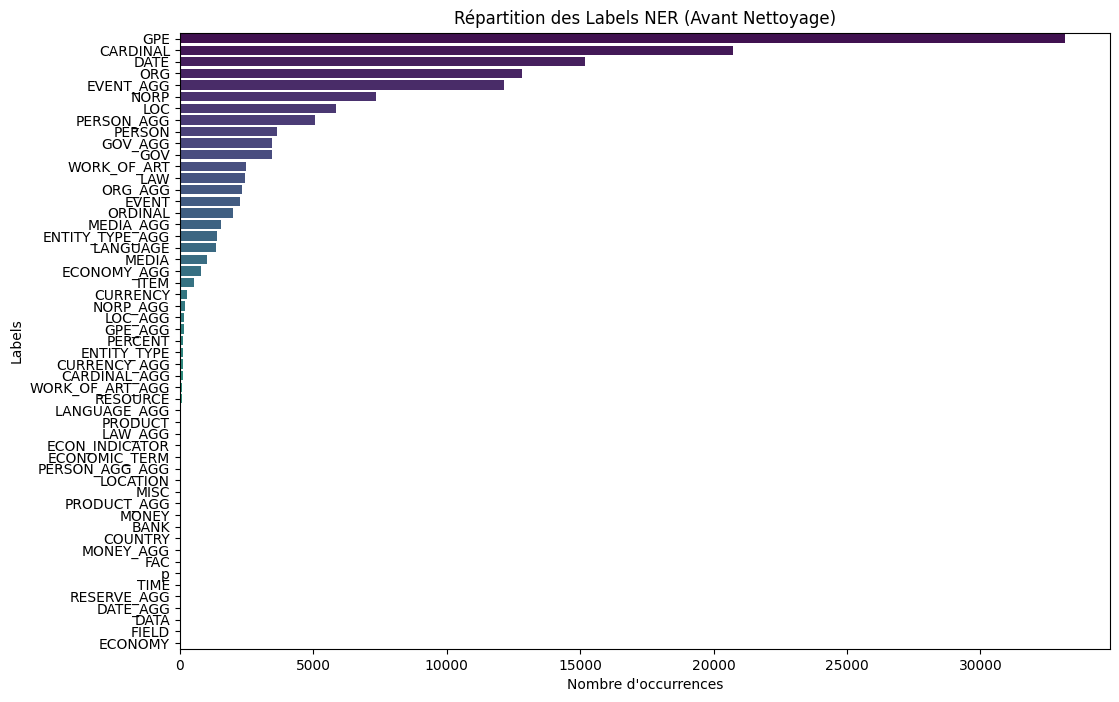

In [10]:
plt.figure(figsize=(12, 8))
order = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=order, palette='viridis')
plt.title('Répartition des Labels NER (Avant Nettoyage)')
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('Labels')
plt.show()


Je vois qu'il ya des entity n'ont pas d'importance et il faut les traiter par exemple :
BANK , TIME ,ECONOMY .. ils sont soit déja une entity qui a le meme reference comme ORG ,DATE ou des entity faut les supp comme FAC FIELD
  
  
il y a aussi des entity faut les fusionner par exemple ORG_AGG pour notre model nous donne plus bons résultats et doubler la puissance

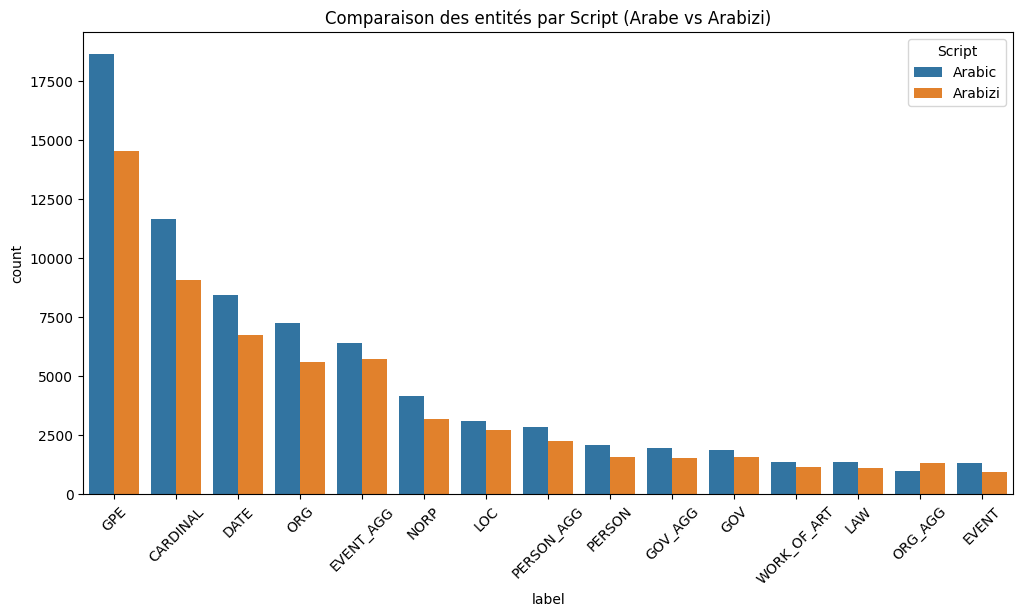

In [11]:
plt.figure(figsize=(12, 6))
# On prend le top 15 pour la lisibilité
top_labels = df['label'].value_counts().head(15).index
df_sub = df[df['label'].isin(top_labels)]

sns.countplot(data=df_sub, x='label', hue='script', order=top_labels)
plt.xticks(rotation=45)
plt.title('Comparaison des entités par Script (Arabe vs Arabizi)')
plt.legend(title='Script')
plt.show()

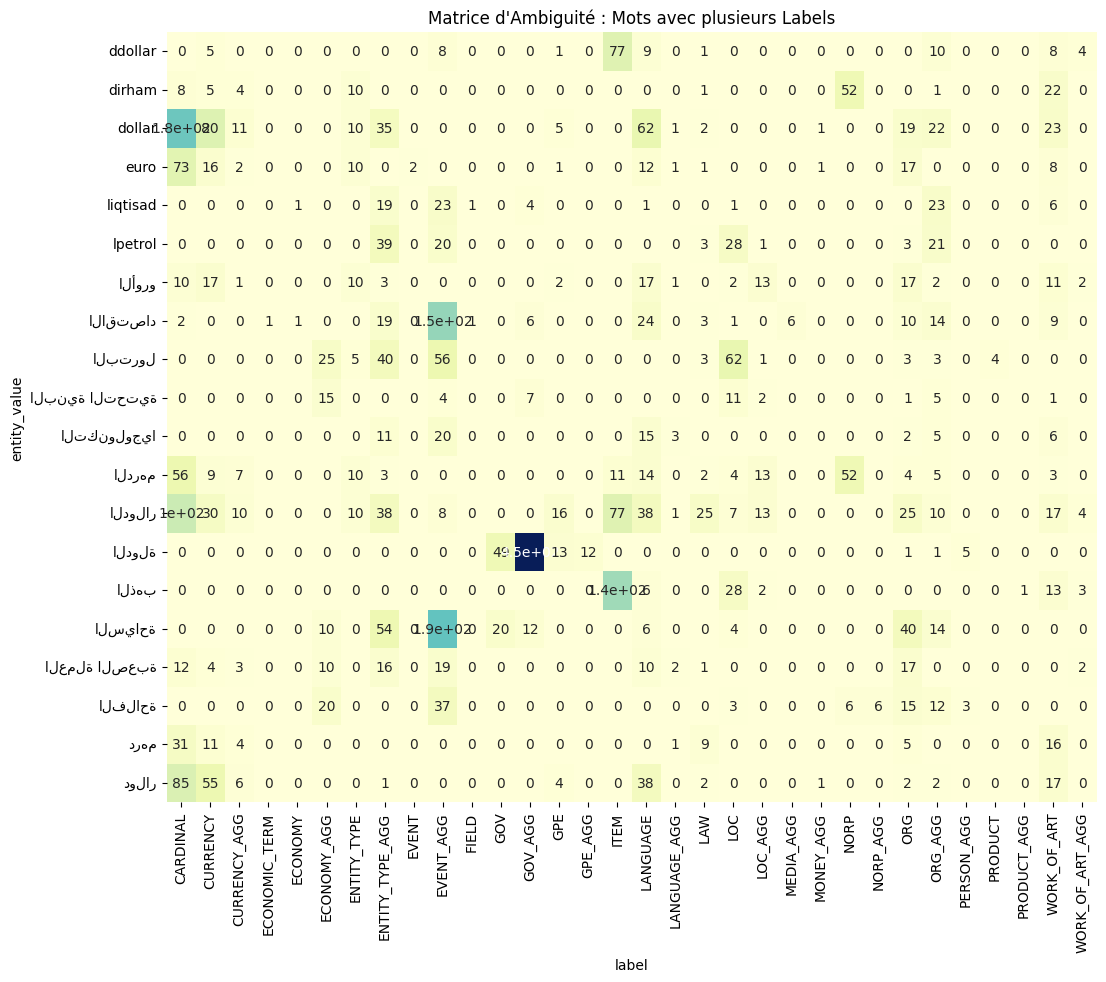

In [12]:
# On cherche les 20 entités les plus fréquentes qui ont plusieurs labels
ambiguity_check = df.groupby('entity_value')['label'].nunique()
ambiguous_words_all = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).index
ambiguous_words = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).head(20).index

df_ambig = df[df['entity_value'].isin(ambiguous_words)]
df_ambig_all = df[df['entity_value'].isin(ambiguous_words_all)]
pivot_ambig = pd.crosstab(df_ambig['entity_value'], df_ambig['label'])

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_ambig, annot=True, cmap="YlGnBu", cbar=False)
plt.title('Matrice d\'Ambiguité : Mots avec plusieurs Labels')
plt.show()

In [13]:
pivot_ambig

label,CARDINAL,CURRENCY,CURRENCY_AGG,ECONOMIC_TERM,ECONOMY,ECONOMY_AGG,ENTITY_TYPE,ENTITY_TYPE_AGG,EVENT,EVENT_AGG,...,MONEY_AGG,NORP,NORP_AGG,ORG,ORG_AGG,PERSON_AGG,PRODUCT,PRODUCT_AGG,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
ddollar,0,5,0,0,0,0,0,0,0,8,...,0,0,0,0,10,0,0,0,8,4
dirham,8,5,4,0,0,0,10,0,0,0,...,0,52,0,0,1,0,0,0,22,0
dollar,185,80,11,0,0,0,10,35,0,0,...,1,0,0,19,22,0,0,0,23,0
euro,73,16,2,0,0,0,10,0,2,0,...,1,0,0,17,0,0,0,0,8,0
liqtisad,0,0,0,0,1,0,0,19,0,23,...,0,0,0,0,23,0,0,0,6,0
lpetrol,0,0,0,0,0,0,0,39,0,20,...,0,0,0,3,21,0,0,0,0,0
الأورو,10,17,1,0,0,0,10,3,0,0,...,0,0,0,17,2,0,0,0,11,2
الاقتصاد,2,0,0,1,1,0,0,19,0,151,...,0,0,0,10,14,0,0,0,9,0
البترول,0,0,0,0,0,25,5,40,0,56,...,0,0,0,3,3,0,4,0,0,0


In [14]:
pivot_ambig_all = pd.crosstab(df_ambig_all['entity_value'], df_ambig_all['label'])
pivot_ambig_all.head(20)

label,BANK,CARDINAL,CARDINAL_AGG,COUNTRY,CURRENCY,CURRENCY_AGG,DATA,DATE,DATE_AGG,ECONOMIC_TERM,...,ORG_AGG,PERCENT,PERSON,PERSON_AGG,PERSON_AGG_AGG,PRODUCT,PRODUCT_AGG,RESOURCE,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
1,0,70,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,144,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
10 snin,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
10 سنين,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,31,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,122,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
123,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13%,0,138,0,0,0,0,0,0,0,0,...,0,4,0,0,0,0,0,0,0,0


In [15]:
# voir les cardinals dollar,ddolar.. groupby entity_value et label la place de fichier, compter les occurrences
df[df['entity_value'].str.contains('dollar|دولار|درهم|اورو|euro|dirham', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(20)


,entity_value,label,file,count
0,1 dollar,CARDINAL,Darija AI Discussion and Tagging - 169.txt,1
1,1 dollar,CARDINAL,Darija NER Tagging Assistant Workflow - 176.txt,1
2,1 dollar,CARDINAL,Darija NER Tagging_ Tourism & Economy - 170.txt,1
3,1 dollar,CARDINAL,Darija Text Analysis and Tagging - 175.txt,1
4,1 dollar,CARDINAL,Disappearance of Bank Al-Maghrib Governor - 16...,1
5,1 dollar,CARDINAL,Global Politics and Moroccan Economy - 167.txt,1
6,1 dollar,CARDINAL,Moroccan Census_ Cost vs. Benefit - 173.txt,1
7,1 dollar,CARDINAL,Moroccan Darija Financial Advice - 160.txt,1
8,1 dollar,CARDINAL,Moroccan Darija Investment Advice - 159.txt,1
9,1 dollar,CARDINAL,Moroccan Darija NER Tagging Assistant - 172.txt,1


In [16]:
df[df['entity_value'].str.contains('lpetrol', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(50)


,entity_value,label,file,count
0,lboldan lmontija l lpetrol,NORP,ارتفاع أسعار المحروقات في المغرب - 32.txt,1
1,lpetrol,ENTITY_TYPE_AGG,Algeria's 2025 Budget Analysis - 224.txt,2
2,lpetrol,ENTITY_TYPE_AGG,Darija Bitcoin Seizure and Auction - 240.txt,2
3,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant - 63.txt,1
4,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 229.txt,2
5,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 235.txt,2
6,lpetrol,ENTITY_TYPE_AGG,Darija Text Tagging and Rewriting - 61.txt,1
7,lpetrol,ENTITY_TYPE_AGG,Moroccan Car Industry Discussion - 227.txt,2
8,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Budget Law Analysis - 225.txt,2
9,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Economic & Social Discussion -...,2


Tableau comparatif entre le nombre total d'occurrences et le nombre de mots uniques (distincts) pour chaque label

--- Comparaison : Total des occurrences vs Mots Uniques par Label ---


,Total Occurrences,Mots Uniques,Ratio Diversité (%)
label,,,
GPE,33186,1116,3.36
CARDINAL,20740,1926,9.29
DATE,15192,1297,8.54
ORG,12828,1686,13.14
EVENT_AGG,12153,1277,10.51
NORP,7346,623,8.48
LOC,5862,741,12.64
PERSON_AGG,5083,746,14.68
PERSON,3651,587,16.08


<Figure size 1400x700 with 0 Axes>

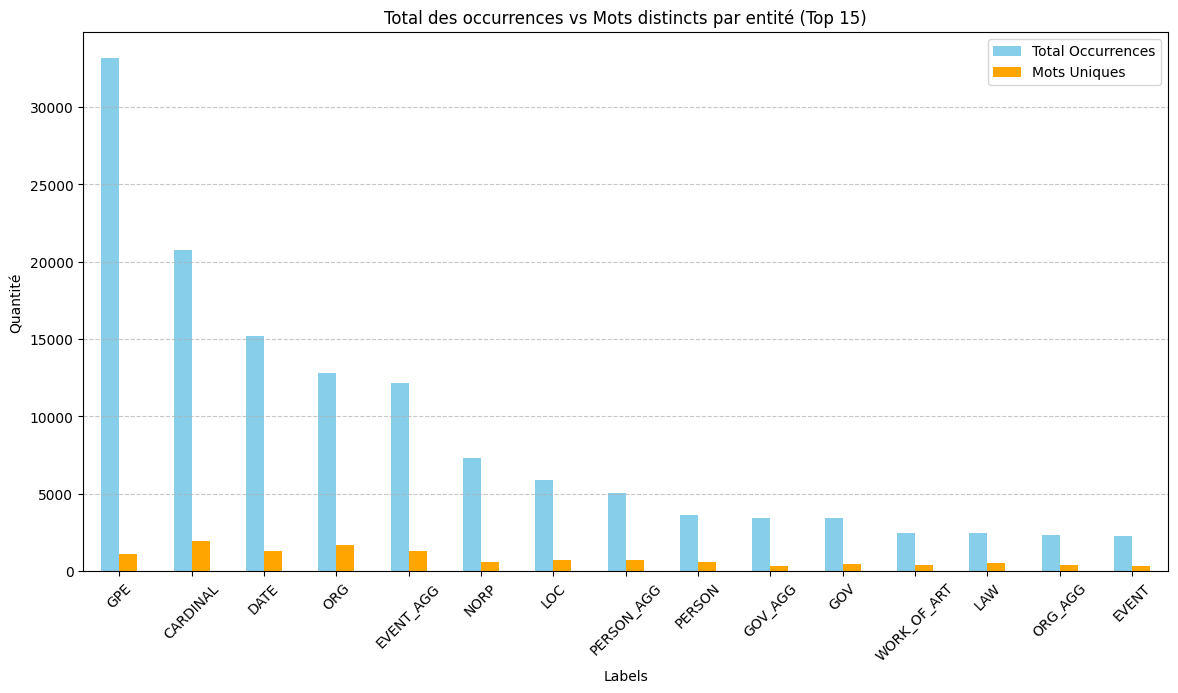

In [17]:
# Calculer le nombre total d'occurrences par label
total_counts = df['label'].value_counts()

# Calculer le nombre d'entités distinctes (uniques) par label
unique_counts = df.groupby('label')['entity_value'].nunique()

# Combiner les deux dans un seul DataFrame pour faciliter la comparaison
comparison_df = pd.DataFrame({
    'Total Occurrences': total_counts,
    'Mots Uniques': unique_counts
})

# Calculer le ratio de diversité (Mots uniques / Total)
# Plus le pourcentage est bas, plus les mots se répètent.
comparison_df['Ratio Diversité (%)'] = (comparison_df['Mots Uniques'] / comparison_df['Total Occurrences'] * 100).round(2)

# Trier par le nombre total d'occurrences
comparison_df = comparison_df.sort_values(by='Total Occurrences', ascending=False)

print("--- Comparaison : Total des occurrences vs Mots Uniques par Label ---")
display(comparison_df)

# Optionnel : Visualisation avec un graphique à barres superposées (pour les 15 premiers)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
comparison_df.head(15)[['Total Occurrences', 'Mots Uniques']].plot(kind='bar', figsize=(14, 7), color=['skyblue', 'orange'])
plt.title("Total des occurrences vs Mots distincts par entité (Top 15)")
plt.xlabel("Labels")
plt.ylabel("Quantité")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Lmachakiil

Alors, nous avons mis le doigt sur les deux problèmes majeurs liés à l'utilisation de LLMs pour la pré-annotation (Étape C de votre cahier des charges) : l'hallucination de labels (inventer des classes qui n'existent pas dans le prompt) et l'imprécision des frontières d'entités (les spans trop courts ou mal ciblés).

#### 1. Regroupement et nettoyage des labels (Mapping)
Votre cahier des charges impose strictement 14 classes. Tous les autres labels doivent être soit ramenés à une de ces 14 classes (ex: BANK → ORG), soit supprimés s'ils ne correspondent à rien de pertinent (ex: ITEM, p, FAC).

Taille du dataset AVANT nettoyage : 142785 entités
Taille du dataset APRÈS mapping et filtrage : 139734 entités
Nombre d'entités hors-sujet supprimées : 3051\n
--- Détail des entités par label ---
label_mapped
GPE                33190
CARDINAL           21264
DATE               15196
ORG                12832
EVENT_AGG          12153
NORP                7346
LOC                 5873
PERSON_AGG          5107
PERSON              3651
GOV_AGG             3462
GOV                 3461
WORK_OF_ART         2499
LAW                 2446
ORG_AGG             2314
EVENT               2251
ORDINAL             1983
MEDIA_AGG           1530
LANGUAGE            1370
MEDIA               1014
NORP_AGG             186
LOC_AGG              172
GPE_AGG              140
CARDINAL_AGG         106
WORK_OF_ART_AGG       86
LANGUAGE_AGG          62
LAW_AGG               40
Name: count, dtype: int64


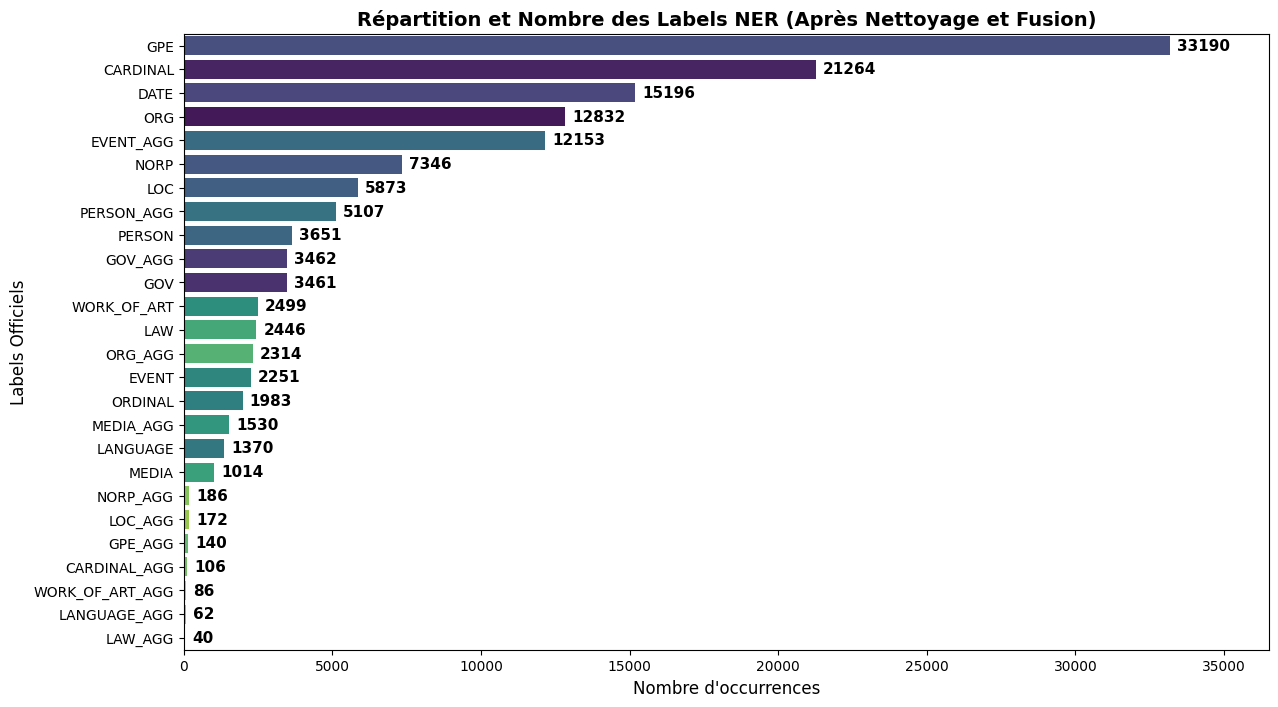

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définir les 14 labels officiels du cahier des charges
official_labels = [
    "PERSON", "NORP", "GPE", "LOC", "ORG", "GOV", "MEDIA",
    "EVENT", "WORK_OF_ART", "LAW", "LANGUAGE", "DATE", "ORDINAL", "CARDINAL" , "PERSON_AGG", "NORP_AGG", "GPE_AGG", "LOC_AGG", "ORG_AGG", "GOV_AGG", "MEDIA_AGG",
    "EVENT_AGG", "WORK_OF_ART_AGG", "LAW_AGG", "LANGUAGE_AGG", "DATE_AGG", "ORDINAL_AGG", "CARDINAL_AGG"
]

# 2. Créer un dictionnaire de mapping pour les erreurs courantes du LLM
label_mapping = {
    # Nettoyage des suffixes "_AGG"
    'PERSON_AGG_AGG': 'PERSON_AGG',

    # Redirection sémantique vers les classes officielles
    'BANK': 'ORG',
    'COUNTRY': 'GPE',
    'LOCATION': 'LOC',
    'TIME': 'DATE',
    'DATE_AGG': 'DATE',

    # L'argent et les pourcentages sont ramenés à CARDINAL
    'CURRENCY': 'CARDINAL', 'CURRENCY_AGG': 'CARDINAL',
    'MONEY': 'CARDINAL', 'MONEY_AGG': 'CARDINAL',
    'PERCENT': 'CARDINAL'
}

# Copie du dataframe pour travailler proprement
df_clean = df.copy()

# Appliquer le mapping
df_clean['label_mapped'] = df_clean['label'].replace(label_mapping)

# Filtrer pour ne garder QUE les 14 classes officielles (cela supprime automatiquement les labels inutiles)
df_clean = df_clean[df_clean['label_mapped'].isin(official_labels)]

# Afficher un résumé des quantités
print(f"Taille du dataset AVANT nettoyage : {df.shape[0]} entités")
print(f"Taille du dataset APRÈS mapping et filtrage : {df_clean.shape[0]} entités")
print(f"Nombre d'entités hors-sujet supprimées : {df.shape[0] - df_clean.shape[0]}\\n")

print("--- Détail des entités par label ---")
print(df_clean['label_mapped'].value_counts())

# Création du graphique avec les nombres sur les barres
plt.figure(figsize=(14, 8))
order = df_clean['label_mapped'].value_counts().index

# On utilise hue='label_mapped' et legend=False pour éviter l'avertissement de Seaborn
ax = sns.countplot(
    data=df_clean,
    y='label_mapped',
    order=order,
    hue='label_mapped',
    palette='viridis',
    legend=False
)

# Boucle pour ajouter le nombre exact à la fin de chaque barre
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

# Ajout des titres et labels
plt.title('Répartition et Nombre des Labels NER (Après Nettoyage et Fusion)', fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'occurrences", fontsize=12)
plt.ylabel("Labels Officiels", fontsize=12)

# Ajuster les marges pour que les nombres ne soient pas coupés
plt.xlim(0, df_clean['label_mapped'].value_counts().max() * 1.1)

plt.show()

#### 2. Détection des problèmes de "Spans" (Frontières des entités)
Pour identifier les entités tronquées (trop courtes) ou les "fuites" où le LLM a annoté une phrase entière (trop longues), nous pouvons analyser la longueur des entités (en nombre de mots et de caractères).

In [36]:
# Calculer le nombre de mots et de caractères pour chaque entité
df_clean['word_count'] = df_clean['entity_value'].apply(lambda x: len(str(x).split()))
df_clean['char_count'] = df_clean['entity_value'].apply(lambda x: len(str(x)))



# --- RECHERCHE D'ANOMALIES ---

# 1. Les entités suspectes car trop longues (Probablement des phrases entières annotées par erreur)
print("--- Entités très longues (Potentielles phrases complètes) ---")
display(df_clean[df_clean['word_count'] > 6][['entity_value', 'label_mapped', 'word_count']].sample(10, random_state=42))

# 2. Les entités d'un seul caractère (Souvent du bruit, de la ponctuation ou des erreurs de tokenization)
print("\\n--- Entités d'un seul caractère (Bruit potentiel) ---")
display(df_clean[df_clean['char_count'] == 1]['entity_value'].value_counts().head(10))

--- Entités très longues (Potentielles phrases complètes) ---


,entity_value,label_mapped,word_count
21556,9 d llil hta l 7 d sbah,DATE,8
2838,markaz dirasa w tafkir 7awl l3alam lfrankofoni,ORG,7
111069,الوكالة المغربية للأمن والسلامة في المجالين ال...,GOV,8
55329,natij dakhili kham</ORG>. Ktab smyto <WORK_OF_...,ORG_AGG,14
86666,9 د الليل حتى ل 7 د الصباح,DATE,8
141272,مولات الملوي</PRODUCT> غيغلى عليها الطياب وغاد...,PERSON_AGG,10
115437,moassasat lma3ayir wal moraja3a lil moassasat ...,ORG,8
62332,الوكالة الوطنية للتدبير الاستراتيجي لمساهمات ا...,ORG,7
7768,itifaqiyat 7imayat torath 3alami ta9afi w tabi3i,LAW,7
132699,الهيئة الوطنية للنزاهة والوقاية من الرشوة ومحا...,GOV,7


\n--- Entités d'un seul caractère (Bruit potentiel) ---


entity_value
5    333
3    238
4    153
7    104
2     83
1     82
6     78
8     44
9     42
x      1
Name: count, dtype: int64

On remarque que le code d'extraction initial (regex) a capturé une grande partie du texte qui incluait accidentellement une autre balise de fermeture comme </PRODUCT> ou </ORG>.

Puisque ces annotations sont structurellement corrompues et incluent du texte hors de l'entité, la meilleure approche est de les détecter via une expression régulière (RegEx) qui cherche la présence de balises HTML/XML, puis de supprimer ces lignes.

le code Python pour détecter et vous débarrasser de ces entités mal formées :

In [37]:
import re

# 1. Détection des entités contenant des balises résiduelles (ex: </PRODUCT> ou <ORG>)
# Le pattern cherche tout ce qui ressemble à des balises ouvrantes ou fermantes avec des lettres majuscules
tag_pattern = r'</?[A-Z_]+>'

# Créer un masque booléen pour trouver ces anomalies dans la colonne 'entity_value'
mask_malformed = df_clean['entity_value'].str.contains(tag_pattern, regex=True, na=False)

print(f"Nombre d'entités mal formées détectées : {mask_malformed.sum()}")

# Afficher quelques exemples avant de les supprimer pour vérifier ce qu'on enlève
if mask_malformed.sum() > 0:
    print("\n--- Exemples d'entités contenant des balises résiduelles ---")
    display(df_clean[mask_malformed][['entity_value', 'label_mapped', 'file']].sample(10))

# 2. Suppression de ces entités (On s'en débarrasse)
# On filtre le dataframe pour ne garder que les lignes qui NE contiennent PAS le pattern (le symbole ~ inverse la condition)
df_clean = df_clean[~mask_malformed].copy()

# Recalculer les longueurs (au cas où, pour mettre à jour les statistiques)
df_clean['word_count'] = df_clean['entity_value'].apply(lambda x: len(str(x).split()))
df_clean['char_count'] = df_clean['entity_value'].apply(lambda x: len(str(x)))

print(f"\nTaille du dataset APRÈS suppression des entités mal formées : {df_clean.shape[0]} entités")

Nombre d'entités mal formées détectées : 134

--- Exemples d'entités contenant des balises résiduelles ---


,entity_value,label_mapped,file
122686,iqtisad watani</ORG> wajdin. Lmohim daba hwa d...,ORG_AGG,Morocco-France Relations And Visa Policy - 171...
348,والي <ORG> بنك المغرب </ORG>,PERSON,Bdarija NER Tagging Task.txt
59366,l9arn <ORDINAL>ssadis</ORDINAL> 3achar,DATE,Moroccan Darija Cuisin History - 280.txt
59426,l9arn <ORDINAL>rrabi3</ORDINAL> 3achar,DATE,Moroccan Darija Cuisin History - 280.txt
122601,iqtisad watani</ORG> wajdin. Lmohim daba hwa d...,ORG_AGG,Morocco-France Relations And Visa Policy - 171...
127498,"mawad awaliya</ORG> mn berra, zaid mochkil <EV...",ORG_AGG,T-shirt Price Difference Morocco vs Europe - 1...
122571,"natij dakhili ijmali</ORG>, w <ORG_AGG>dyon",ORG_AGG,Morocco-France Relations And Visa Policy - 171...
30196,"mawad awaliya</ORG> mn berra, zaid mochkil <EV...",ORG_AGG,Darija NER Tagging Assistant Workflow - 176.txt
127413,"mawad awaliya</ORG> mn berra, zaid mochkil <EV...",ORG_AGG,T-shirt Price Difference Morocco vs Europe - 1...
122668,natij dakhili kham</ORG>. Ktab smyto <WORK_OF_...,ORG_AGG,Morocco-France Relations And Visa Policy - 171...



Taille du dataset APRÈS suppression des entités mal formées : 139600 entités


##### Dakchi nadi, ghir chi chyata b7al </Product> w kda khashom ytero !!

#### 3. Recherche de caractères parasites et nettoyage de texte
Souvent, les LLMs incluent la ponctuation environnante dans le span (ex: "lmaghrib," au lieu de "lmaghrib"), ce qui est mauvais pour entraîner un modèle NER.

In [ ]:
import re

# 1. Définir l'expression régulière pour cibler EXCLUSIVEMENT <PRODUCT> et </PRODUCT> (insensible à la casse)
product_pattern = r'(?i)</?PRODUCT>'

# 2. DÉTECTION : Trouver les lignes contenant spécifiquement ces balises
mask_has_product = df_clean['entity_value'].str.contains(product_pattern, regex=True, na=False)
df_product_tags = df_clean[mask_has_product]

print(f"Nombre d'entités contenant des balises PRODUCT : {len(df_product_tags)}\n")
if len(df_product_tags) > 0:
    print("--- Exemples d'entités AVANT nettoyage ---")
    display(df_product_tags[['entity_value', 'label_mapped', 'word_count']].head())

# 3. NETTOYAGE : Supprimer UNIQUEMENT ces balises spécifiques
df_clean['entity_value'] = df_clean['entity_value'].str.replace(product_pattern, '', regex=True).str.strip()

# 4. Mettre à jour les compteurs
df_clean['word_count'] = df_clean['entity_value'].apply(lambda x: len(str(x).split()))
df_clean['char_count'] = df_clean['entity_value'].apply(lambda x: len(str(x)))

if len(df_product_tags) > 0:
    print("\n--- Exemples d'entités APRÈS nettoyage ---")
    display(df_clean.loc[df_product_tags.index, ['entity_value', 'label_mapped', 'word_count']].head())

Nombre d'entités avec de la ponctuation suspecte aux extrémités : 153

--- Exemples d'entités mal délimitées par le LLM ---


,entity_value,label_mapped
76524,المكتب الوطني للسكك الحديدية (ONCF),ORG
62394,lwakala lwataniya liltadbir listratiji limasah...,ORG
20322,البراق (TGV),WORK_OF_ART
52344,lmaktab lwatani lissikak lhadidiya (ONCF),ORG
20397,lwakala lwataniya liltadbir listratiji limasah...,ORG
76522,صناديق الخزينة (CST),GOV
57974,lwakala lwataniya liltadbir listratiji limasah...,ORG
82183,البراق (TGV),WORK_OF_ART
50410,sanadiq lkhazina (CST),GOV
20399,lkhotot lmalakiya lmghribiya (RAM),ORG


#### 4. Vérification de la cohérence Script / Texte

Vous avez une colonne script (Arabic vs Arabizi). Il est intéressant de vérifier si le LLM ne s'est pas trompé (ex: un mot classé "Arabic" mais qui ne contient que des lettres latines).

c'est pour cela :

*Le Code Python d'extraction des annotations a corriger :*

In [ ]:
import os
import re
import json

def extract_code_switching_anomalies():
    input_dirs = ['../data/chatgpt_ner', '../data/Gemini_NER_data']
    output_dir = '../data_false_code'

    os.makedirs(output_dir, exist_ok=True)

    entity_pattern = re.compile(r'<([A-Z_]+)>\s*(.*?)\s*</\1>')
    arabic_chars = re.compile(r'[\u0600-\u06FF]')
    latin_chars = re.compile(r'[a-zA-Z]')

    anomalies = set()

    for input_dir in input_dirs:
        if not os.path.exists(input_dir):
            continue

        for filename in os.listdir(input_dir):
            if not filename.endswith('.txt'):
                continue

            filepath = os.path.join(input_dir, filename)
            with open(filepath, 'r', encoding='utf-8') as f:
                current_mode = None

                for line in f:
                    line_upper = line.upper()
                    if 'TEXT (ARABIC)' in line_upper or 'TAG_TEXT (ARABIC)' in line_upper:
                        current_mode = 'ARABIC'
                        continue
                    elif 'ARABIZI' in line_upper:
                        current_mode = 'ARABIZI'
                        continue

                    if not current_mode:
                        continue

                    matches = entity_pattern.findall(line)
                    for label, entity in matches:
                        entity = entity.strip()

                        if current_mode == 'ARABIC' and latin_chars.search(entity):
                            anomalies.add((current_mode, label, entity))

                        elif current_mode == 'ARABIZI' and arabic_chars.search(entity):
                            anomalies.add((current_mode, label, entity))

    output_data = []
    for mode, label, entity in sorted(list(anomalies)):
        output_data.append({
            "section": mode,
            "label": label,
            "entity": entity
        })

    output_file = os.path.join(output_dir, 'anomalies_to_fix.json')
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)

if __name__ == "__main__":
    extract_code_switching_anomalies()

*les corriger en utilisant gemini api key*

In [ ]:
import json
import time
import re
import os
from google import genai
from google.genai import types

# 1. Configuration de la NOUVELLE API Gemini (Remplacez par votre clé)
client = genai.Client(api_key="EnterKeyDyalek")

def generer_dictionnaire_correction(input_file='../data_false_code/anomalies_to_fix.json',
                                    output_file='../data_false_code/correction_dict.json',
                                    batch_size=40):

    # Charger les anomalies
    if not os.path.exists(input_file):
        print(f"Le fichier {input_file} n'existe pas.")
        return

    with open(input_file, 'r', encoding='utf-8') as f:
        anomalies = json.load(f)

    correction_dict = {}
    print(f"Début du traitement de {len(anomalies)} anomalies en lots de {batch_size}...")

    # Traitement par lots (batches)
    for i in range(0, len(anomalies), batch_size):
        batch = anomalies[i:i+batch_size]
        numero_lot = i // batch_size + 1
        print(f"Traitement du lot {numero_lot} ({i+1} à {min(i+batch_size, len(anomalies))})...")

        prompt = f"""
        Tu es un linguiste expert en Darija marocaine (arabe marocain et arabizi).
        Voici une liste d'entités qui ont été écrites avec le mauvais alphabet.

        Règles strictes de correction :
        1. Si "section" == "ARABIC" : L'entité est en caractères latins (Arabizi). Tu dois la translittérer en caractères ARABES. (ex: "lmaghrib" -> "المغرب")
        2. Si "section" == "ARABIZI" : L'entité est en caractères arabes. Tu dois la translittérer en ARABIZI (caractères latins). (ex: "مصر" -> "masr")

        Renvoie UNIQUEMENT un objet JSON valide où la clé est l'entité originale et la valeur est l'entité corrigée.
        Ne rajoute aucun texte avant ou après le JSON.

        Données à traiter :
        {json.dumps(batch, ensure_ascii=False, indent=2)}
        """

        try:
            # Appel à la nouvelle API avec configuration JSON forcée
            response = client.models.generate_content(
                model='gemini-2.5-flash', # Utilisation du dernier modèle rapide
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json", # Force le modèle à renvoyer du JSON propre
                    temperature=0.1 # Température basse pour éviter les hallucinations
                )
            )

            response_text = response.text

            # Extraction du JSON
            try:
                batch_dict = json.loads(response_text)
            except json.JSONDecodeError:
                # Sécurité supplémentaire au cas où il y a des balises Markdown
                json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response_text, re.DOTALL)
                if json_match:
                    batch_dict = json.loads(json_match.group(1))
                else:
                    raise ValueError("Impossible de décoder la réponse en JSON.")

            # Ajouter les corrections au dictionnaire global
            correction_dict.update(batch_dict)

            # Petite pause pour éviter le Rate Limiting (limite de requêtes)
            time.sleep(3)

        except Exception as e:
            print(f"Erreur lors du traitement du lot {numero_lot} : {e}")

    # Sauvegarder le dictionnaire de correction final
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(correction_dict, f, ensure_ascii=False, indent=4)

    print(f"\nTerminé ! {len(correction_dict)} mots corrigés ont été sauvegardés dans '{output_file}'.")

# Exécuter la fonction
if __name__ == "__main__":
    generer_dictionnaire_correction()

In [28]:
# Calculer le nombre total d'occurrences par label
total_counts = df_clean['label_mapped'].value_counts()

# Calculer le nombre d'entités distinctes (uniques) par label
unique_counts = df_clean.groupby('label_mapped')['entity_value'].nunique()

# Combiner les deux dans un seul DataFrame pour faciliter la comparaison
comparison_df = pd.DataFrame({
    'Total Occurrences': total_counts,
    'Mots Uniques': unique_counts
})

# Calculer le ratio de diversité (Mots uniques / Total)
# Plus le pourcentage est bas, plus les mots se répètent.
comparison_df['Ratio Diversité (%)'] = (comparison_df['Mots Uniques'] / comparison_df['Total Occurrences'] * 100).round(2)

# Trier par le nombre total d'occurrences
comparison_df = comparison_df.sort_values(by='Total Occurrences', ascending=False)

print("--- Comparaison : Total des occurrences vs Mots Uniques par Label ---")
display(comparison_df)

--- Comparaison : Total des occurrences vs Mots Uniques par Label ---


,Total Occurrences,Mots Uniques,Ratio Diversité (%)
label_mapped,,,
GPE,33190,1117,3.37
CARDINAL,21264,1958,9.21
DATE,15196,1299,8.55
ORG,12832,1686,13.14
EVENT_AGG,12153,1277,10.51
NORP,7346,623,8.48
LOC,5873,745,12.69
PERSON_AGG,5107,746,14.61
PERSON,3651,587,16.08


In [ ]:
df['label'].value_counts()

# Calculer le nombre d'entités distinctes (uniques) par label
unique_counts = 

In [ ]:
df.groupby('label')['entity_value'].nunique()

# Combiner les deux dans un seul DataFrame pour faciliter la comparaison
comparison_df = pd.DataFrame({
    'Total Occurrences': total_counts,
    'Mots Uniques': unique_counts
})

# Calculer le ratio de diversité (Mots uniques / Total)
# Plus le pourcentage est bas, plus les mots se répètent.
comparison_df['Ratio Diversité (%)'] = (comparison_df['Mots Uniques'] / comparison_df['Total Occurrences'] * 100).round(2)

# Trier par le nombre total d'occurrences
comparison_df = comparison_df.sort_values(by='Total Occurrences', ascending=False)

print("--- Comparaison : Total des occurrences vs Mots Uniques par Label ---")
display(comparison_df)